**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

Mentoría 17 - Inventarios Forestales Nacionales, calculo de biomasa y evaluación del estado de los bosques nativos.

GRUPO 1

Mentor:

Anibal Cuchietti

*Edición 2025*

----

### Práctico 2 de análisis exploratorio y curación de datos

Determinar datos extraños con metodos bivariados (bagplot) de las variables medidas a los arboles de las unidades de muestreo del inventario nacional. Determinar datos faltantes y completar la base de datos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import missingno as msno

from sklearn.impute         import SimpleImputer
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition  import PCA


### Data frame con datos generales:

In [2]:
url = 'https://github.com/poggiogu/DiploDatos2025_Mentoria_17/raw/refs/heads/master/Data/2INBN_Tabla_general_2021.csv'
df_general = pd.read_csv(url, encoding='latin1')
#df_general.head(3)

In [3]:
columnas_num = df_general.select_dtypes(include=['number']).columns.tolist()
columnas_cat = df_general.select_dtypes(exclude=['number']).columns.tolist()

print("Columnas numéricas:", columnas_num)
print("Columnas categóricas:", columnas_cat)

Columnas numéricas: ['UM_ID_UM', 'PROVINCIA', 'MEDIA_ALTURA_UM_EST', 'SUMA_DAP_X_UM', 'AREA_BASAL_UM_HA', 'VOL_M3_HA', 'CANTIDAD_IND_VIVOS_UM', 'CANTIDAD_IND_VIVOS_HA', 'PORCENTAJE_COB_3', 'PORCENTAJE_COB_7', 'PORCENTAJE_COB_TOTAL', 'PORCENTAJE_COB_ARBUSTIVA', 'PORCENTAJE_COB_INFERIOR', 'MEDIA_ALT_TOCONES', 'MEDIA_DAB_TOCONES', 'CANTIDAD_TOCONES_X_UM', 'CANTIDAD_TOCONES_X_HA', 'REGENERACION_UM', 'REGENERACION_HA', 'LONGITUD_GRILLA', 'LATITUD_GRILLA', 'LONGITUD_INSTALACION', 'LATITUD_INSTALACION', 'ALTITUD', 'FECHA_UM_ANIO', 'FECHA_UM_MES']
Columnas categóricas: ['REGION_OFC', 'SUBREG', 'PENDIENTE_CATEGORIA', 'EXPOSICION', 'OTBN_CATEGORIA', 'TIPO_PAISAJE', 'SALINIDAD_PRESENCIA', 'INCENDIOS_RASTROS', 'PASTOREO_PRESENCIA', 'GANADO_BOVINO', 'GANADO_OVINO', 'GANADO_CAPRINO', 'GANADO_EQUINO', 'GANADO_OTRO', 'GANADO_OTRO_TIPO', 'EROSION_PRESENCIA', 'EROSION_FISICA_PRESENCIA', 'EROSION_EOLICA_PRESENCIA', 'EROSION_HIDRICA_PRESENCIA', 'PFNM_PRESENCIA_RESUMEN', 'PFNM_REGISTRO_1', 'PFNM_REGISTRO_2

In [4]:
# creación de un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_general_c = df_general.copy()

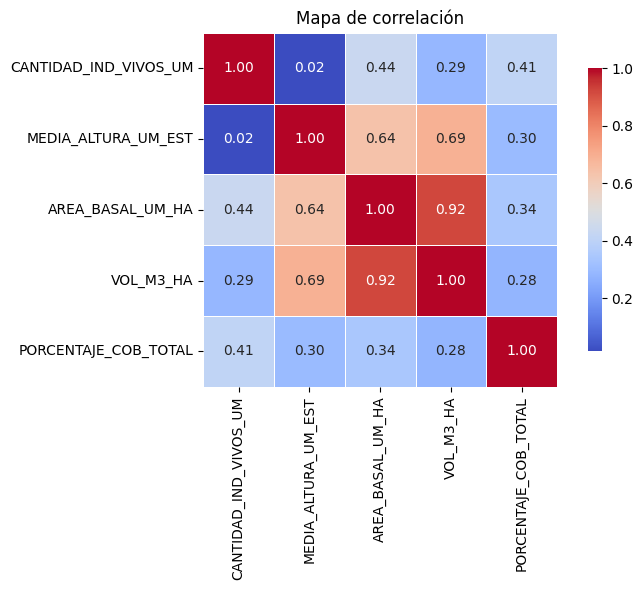

In [5]:

variables = ['CANTIDAD_IND_VIVOS_UM', 'MEDIA_ALTURA_UM_EST', 'AREA_BASAL_UM_HA', 
             'VOL_M3_HA', 'PORCENTAJE_COB_TOTAL']

# Eliminar filas con valores faltantes en estas columnas
df_corr = df_general_c[variables].dropna()

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')  # podés cambiar a 'spearman' si querés

# Crear el mapa de calor
plt.figure(figsize=(8,6))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

En este dataframe se observa una alta correlación entre algunas de las variables de interés seleccionadas. Por lo tanto, se espera que los valores de estas variables sean similares entre sí. Con este criterio, se identificarán y reemplazarán por `NaN` aquellos datos que resulten *outliers conjuntos* entre pares de variables. Para ello, se consideran los valores que se encuentran fuera de la región de mayor densidad conjunta en la distribución de cada par de variables analizado.


#### Par de variables: Altura media por unidad de muestreo vs Volumen comercial de madera por hectárea

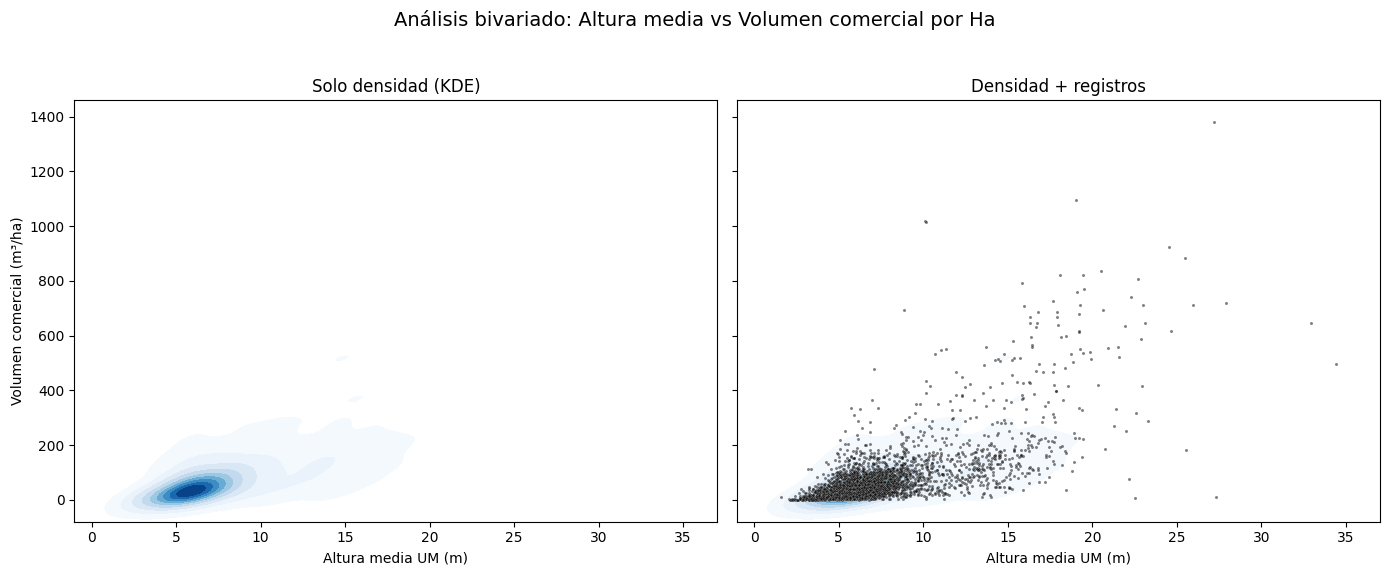

In [6]:
# Eliminar nulos
df = df_general_c.copy()
datos = df[['MEDIA_ALTURA_UM_EST', 'VOL_M3_HA']].dropna()

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Subplot 1: Solo KDE ---
sb.kdeplot(
    x=datos['MEDIA_ALTURA_UM_EST'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05,
    ax=axes[0]
)
axes[0].set_title("Solo densidad (KDE)")
axes[0].set_xlabel("Altura media UM (m)")
axes[0].set_ylabel("Volumen comercial (m³/ha)")

# --- Subplot 2: KDE + scatter ---
sb.kdeplot(
    x=datos['MEDIA_ALTURA_UM_EST'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05,
    ax=axes[1]
)
sb.scatterplot(
    x=datos['MEDIA_ALTURA_UM_EST'], 
    y=datos['VOL_M3_HA'], 
    color='black', 
    s=5, 
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Densidad + registros")
axes[1].set_xlabel("Altura media UM (m)")
axes[1].set_ylabel("Volumen comercial (m³/ha)")

# Ajustar diseño
plt.suptitle("Análisis bivariado: Altura media vs Volumen comercial por Ha", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [7]:
print("Cantidad de filas antes de reemplazar outliers por NaN:", df.shape[0])

# Condición de outliers
cond_outliers = (df['MEDIA_ALTURA_UM_EST'] > 20) & (df['VOL_M3_HA'] > 400)

# Reemplazar con NaN
df.loc[cond_outliers, ['MEDIA_ALTURA_UM_EST', 'VOL_M3_HA']] = np.nan

print("Cantidad de valores NaN después del reemplazo:")
print(df[['MEDIA_ALTURA_UM_EST', 'VOL_M3_HA']].isna().sum())

Cantidad de filas antes de reemplazar outliers por NaN: 3891
Cantidad de valores NaN después del reemplazo:
MEDIA_ALTURA_UM_EST     97
VOL_M3_HA              117
dtype: int64


#### Par de variables: Área basal media por unidad de muestreo vs Volumen comercial de madera por hectárea

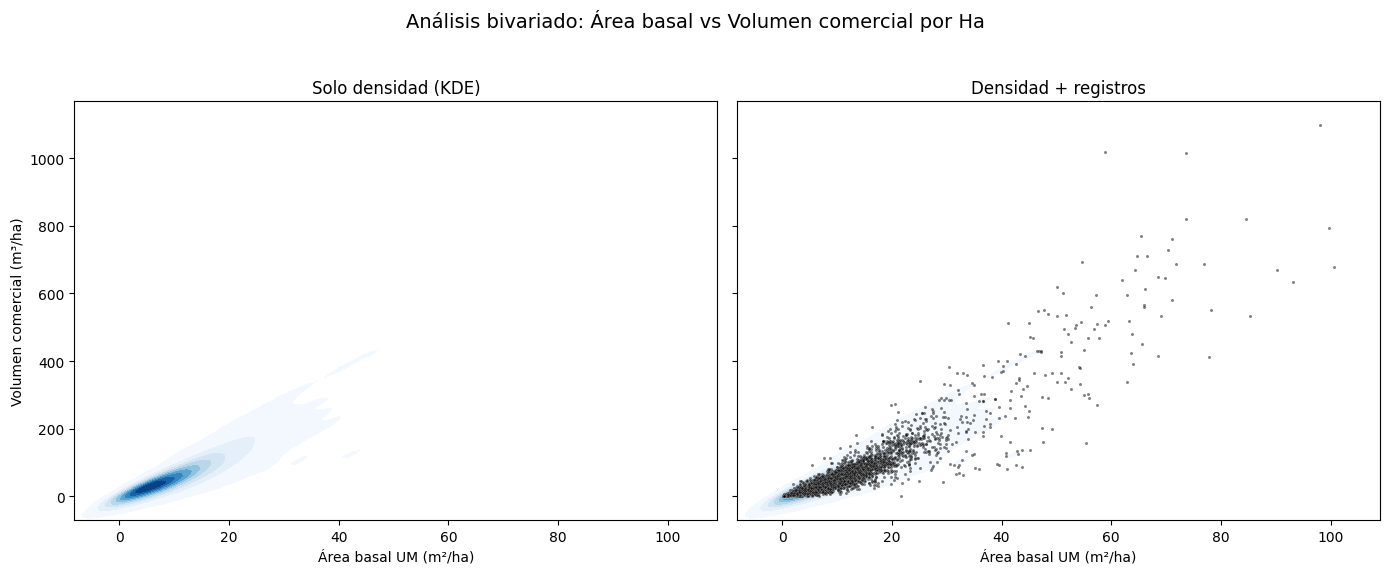

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

# Eliminar nulos
datos = df[['AREA_BASAL_UM_HA', 'VOL_M3_HA']].dropna()

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# --- Subplot 1: Solo KDE ---
sb.kdeplot(
    x=datos['AREA_BASAL_UM_HA'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05,
    ax=axes[0]
)
axes[0].set_title("Solo densidad (KDE)")
axes[0].set_xlabel("Área basal UM (m²/ha)")
axes[0].set_ylabel("Volumen comercial (m³/ha)")

# --- Subplot 2: KDE + scatter ---
sb.kdeplot(
    x=datos['AREA_BASAL_UM_HA'], 
    y=datos['VOL_M3_HA'], 
    fill=True, 
    cmap='Blues', 
    thresh=0.05,
    ax=axes[1]
)
sb.scatterplot(
    x=datos['AREA_BASAL_UM_HA'], 
    y=datos['VOL_M3_HA'], 
    color='black', 
    s=5, 
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Densidad + registros")
axes[1].set_xlabel("Área basal UM (m²)")
axes[1].set_ylabel("Volumen comercial (m³/ha)")

# Ajustar diseño
plt.suptitle("Análisis bivariado: Área basal vs Volumen comercial por Ha", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
from scipy.stats import gaussian_kde

# Elegir las dos variables
x = df['VOL_M3_HA']
y = df['AREA_BASAL_UM_HA']

# Máscara para valores no nulos
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Crear copia del DataFrame sin NaN en esas dos columnas
df_clean = df[mask].copy()

# Crear matriz 2xN para KDE
xy = np.vstack([x_valid, y_valid])

# Estimar densidad
kde = gaussian_kde(xy)
densidades = kde(xy)

# Umbral de densidad (e.g., eliminar el 5% más bajo)
umbral = np.percentile(densidades, 5)

# Detectar outliers conjuntos (densidad menor al umbral)
outliers_mask = densidades <= umbral

# Índices de los valores a reemplazar por NaN
indices_outliers = df_clean.index[outliers_mask]

# Reemplazar por NaN en las columnas seleccionadas
df.loc[indices_outliers, ['VOL_M3_HA', 'AREA_BASAL_UM_HA']] = np.nan

# (Opcional) Ver cuántos valores fueron convertidos a NaN
print(f"Cantidad de filas originales: {len(df)}")
print(f"Cantidad de valores reemplazados por NaN: {len(indices_outliers)}")


Filas originales: 3870
Filas después de filtrar outliers: 3585


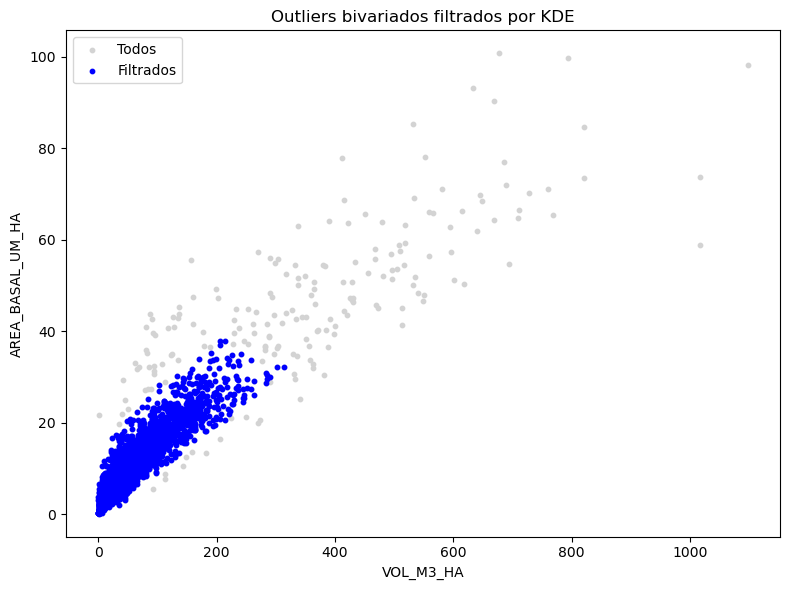

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, c='lightgray', s=10, label='Todos')
plt.scatter(df['VOL_M3_HA'], df['AREA_BASAL_UM_HA'],
            c='blue', s=10, label='Filtrados')
plt.xlabel('VOL_M3_HA')
plt.ylabel('AREA_BASAL_UM_HA')
plt.title('Outliers bivariados filtrados por KDE')
plt.legend()
plt.tight_layout()
plt.show()

Así quedan filtrados datos que corresponden a valores muy extremos de estas dos variables. 

----
----

## Data frame con datos de individuos:

#### En este data frame optamos por preservar la totalidad de los registros y descartar las variables redundantes (columnas con información duplicada), así como aquellas con baja completitud de datos (muy pocos valores no nulos).
#### Posteriormente, generaremos nuevas columnas numéricas a partir de variables categóricas con pocas clases, aplicándoles one-hot encoding. Estas nuevas variables numéricas —binarias, con valores posibles [0, 1]— podrán utilizarse más adelante para entrenar modelos de aprendizaje automático, tanto de clasificación como de clustering.
#### También trabajaremos con PCA para establecer los componentes principales, por lo que deberemos escalar e imputar los valores numéricos NaN.

### Lectura del dataframe:

In [301]:
url2 = 'https://raw.githubusercontent.com/poggiogu/DiploDatos2025_Mentoria_17/refs/heads/master/Data/data_individuos_pais_2021.csv'
df_individuos = pd.read_csv(url2, low_memory=False)
#df_individuos.head(3)
df_individuos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101229 entries, 0 to 101228
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   UM_ID_UM                    101229 non-null  int64  
 1   NO_INDIV                    101229 non-null  int64  
 2   PARCELA_CONCENTRICA         101229 non-null  object 
 3   ESPECIE_CORREGIDA           101229 non-null  object 
 4   REGION_OFC                  101229 non-null  object 
 5   SUBREG                      96093 non-null   object 
 6   ESTADO_INDIV                101229 non-null  object 
 7   ALTURA_TOTAL_M              101226 non-null  float64
 8   PROVINCIA                   101229 non-null  int64  
 9   COORDENADAS_GPS_LATITUDE2   101229 non-null  float64
 10  COORDENADAS_GPS_LONGITUDE2  101229 non-null  float64
 11  DAP_FINAL_M                 101229 non-null  float64
 12  ALTURA_TOTAL_EST            101229 non-null  float64
 13  VOL_M3        

In [302]:
columnas_num_ind= df_individuos.select_dtypes(include=['number']).columns.tolist()
columnas_cat_ind = df_individuos.select_dtypes(exclude=['number']).columns.tolist()

print("Columnas numéricas:", columnas_num_ind)
print("Columnas categóricas:", columnas_cat_ind)

Columnas numéricas: ['UM_ID_UM', 'NO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA', 'COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2', 'DAP_FINAL_M', 'ALTURA_TOTAL_EST', 'VOL_M3', 'VOL_M3_HA', 'DAP_CM', 'AREABASAL_CM2', 'AREABASAL_M2', 'DENSIDAD_MADERA', 'BIOMASA_KG', 'CARBONO_KG', 'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'MEDIA_DIAM_COPA', 'DAB_FINAL_M', 'DIAMETRO_COPA_1', 'DIAMETRO_COPA_2', 'DAB_CM']
Columnas categóricas: ['PARCELA_CONCENTRICA', 'ESPECIE_CORREGIDA', 'REGION_OFC', 'SUBREG', 'ESTADO_INDIV', 'CLASE_DIAM', 'Ley_N1_06', 'Ley_N2_06']


In [303]:
# creación de un DF copia para poder alterar y realizar comparaciones en bloques de código posteriores:
df_individuos_c = df_individuos.copy()

##### Boxplots de variables con evidentes  outliers:

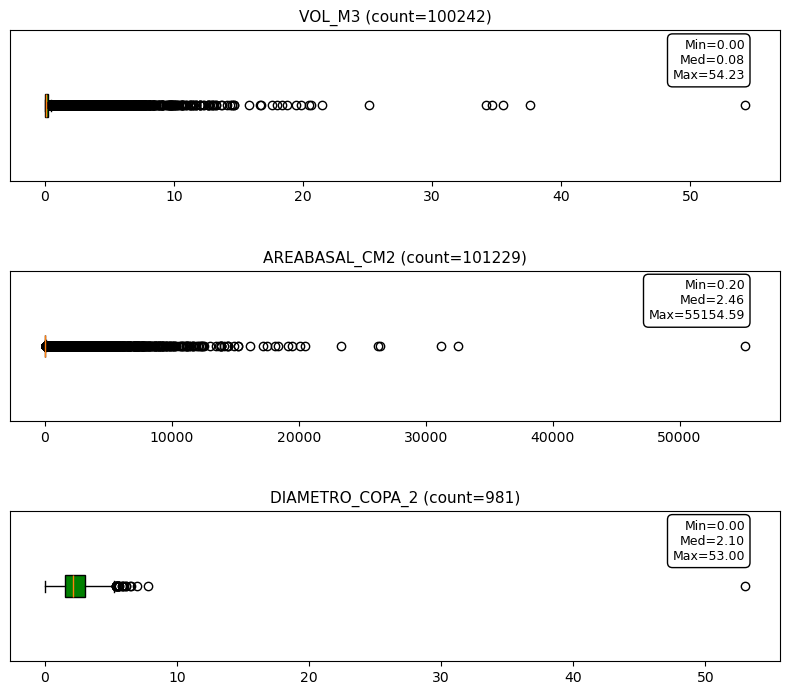

In [304]:
cols_ind = ['VOL_M3', 'AREABASAL_CM2', 'DIAMETRO_COPA_2'] # 'AREABASAL_CM2', 'AREABASAL_M2' // 'VOL_M3', 'VOL_M3_HA' // 

n = len(cols_ind)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 2.5 * n), sharex=False)

if n == 1:
    axes = [axes]

for i, col in enumerate(cols_ind):
    data = df_individuos_c[col].dropna()
    count = data.count()
    ax = axes[i]
    bp = ax.boxplot(data, vert=False, patch_artist=True) # vert=false ---> horizontal
    for box in bp['boxes']:
        box.set_facecolor('green')
    ax.set_title(f"{col} (count={count})", fontsize=11)
    ax.set_yticks([])
    percentiles = data.quantile([0.0, 0.5, 1.0])
    min_val = percentiles.loc[0.0]
    med_val = percentiles.loc[0.5]
    max_val = percentiles.loc[1.0]
    label_text = f"Min={min_val:.2f}\nMed={med_val:.2f}\nMax={max_val:.2f}"
    # Posición dentro del boxplot
    x_pos = max_val - (max_val - min_val) * 0.00  
    y_pos = 1.3  
    ax.text(
        x_pos, y_pos,
        label_text,
        ha='right', va='center',
        fontsize=9, color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.6)
plt.show()

- Analizamos los casos mencionados donde observamos outliers

In [305]:
# print(df_individuos.loc[df_individuos['VOL_M3'] >= 30, 'DAP_FINAL_M']) # vemos el valor de DAB_FINAL_M oara estos registros
df_individuos_c[df_individuos_c['VOL_M3'] >= 30]

,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,...,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06
55325,54164045,4,A,Peltophorum dubium,SMI,Selva Paranaense,2,29.6,54,-25.580194,...,>=120,440.959387,211.660505,NaN,NaN,NaN,NaN,NaN,TF,Bosque cerrado
60747,66058034,6,A,Ocotea porphyria,STB,NaN,1,30.2,66,-24.836889,...,>=120,162.233823,77.872235,NaN,NaN,NaN,NaN,NaN,TF,Selva de transicion
61402,66060006,13,A,Terminalia triflora,STB,NaN,1,23.0,66,-22.312000,...,>=120,200.808284,96.387976,NaN,NaN,NaN,NaN,NaN,TF,Selva montana
98214,90052057,10,A,Ocotea porphyria,STB,NaN,2,12.9,90,-26.902722,...,>=120,267.074962,128.195982,NaN,NaN,NaN,NaN,NaN,TF,Selva montana
98226,90052057,21,A,Ocotea porphyria,STB,NaN,1,15.8,90,-26.902722,...,>=120,327.577090,157.237003,NaN,NaN,NaN,NaN,NaN,TF,Selva montana


In [306]:
df_individuos_c[df_individuos_c['AREABASAL_CM2'] >= 30000]

,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,...,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06
24305,26002238,17,A,Nothofagus pumilio,BAP,Bosque Andino Patagónico,1,26.0,26,-42.875306,...,>=120,344.134840,165.184723,NaN,NaN,NaN,NaN,NaN,TF,Le
55325,54164045,4,A,Peltophorum dubium,SMI,Selva Paranaense,2,29.6,54,-25.580194,...,>=120,440.959387,211.660505,NaN,NaN,NaN,NaN,NaN,TF,Bosque cerrado
98226,90052057,21,A,Ocotea porphyria,STB,NaN,1,15.8,90,-26.902722,...,>=120,327.577090,157.237003,NaN,NaN,NaN,NaN,NaN,TF,Selva montana


In [307]:
df_individuos_c[df_individuos_c['DIAMETRO_COPA_2'] >= 50]

,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,...,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06
53105,50033145,8,B,Prosopis flexuosa,MON,Monte,3,2.6,50,-34.769139,...,[60-70],31.571145,15.154149,29.4,0.2078,5.8,53.0,65.1,OTF,Estepa arbustiva


- Luego de analizar los registros de los casos que muestran outliers, el único que aparentemente corresponde a un dato mal tomado o mal cargado es el del individuo con un valor de DIAMETRO_COPA_2 mayor a 50 metros. Este registro pertenece a un árbol de la especie Prosopis flexuosa (de la subregión de “Monte”), la cual no debería alcanzar un tamaño semejante y cuyos demás datos tampoco coinciden (por ejemplo, su valor de ALTURA_TOTAL_M es de apenas 2.6 metros).
Este valor podría convertirse en NaN para ser imputado luego, pero se decidirá más adelante en base a la cantidad de valores nulos de esa variable. 

- Los outliers encontrados en los valores de VOL_M3 y AREABASAL_CM2 coinciden con los rangos posibles para las especies detalladas en cada registro, por lo que se consideran válidos.

##### Visualizamos valores Nulos en el dataset:

<Axes: >

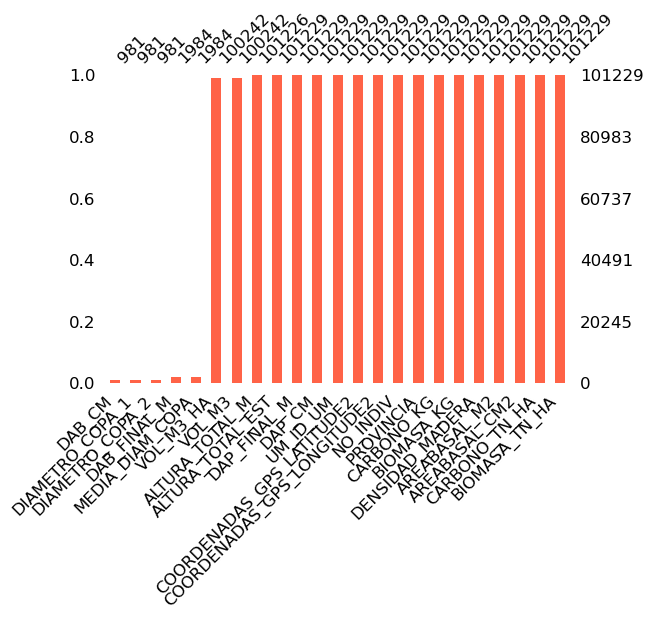

In [308]:
msno.bar(df_individuos_c[columnas_num_ind],figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

In [309]:
df_individuos_c[(df_individuos_c['MEDIA_DIAM_COPA'] >= 0)].head(3)

,UM_ID_UM,NO_INDIV,PARCELA_CONCENTRICA,ESPECIE_CORREGIDA,REGION_OFC,SUBREG,ESTADO_INDIV,ALTURA_TOTAL_M,PROVINCIA,COORDENADAS_GPS_LATITUDE2,...,CLASE_DIAM,BIOMASA_TN_HA,CARBONO_TN_HA,MEDIA_DIAM_COPA,DAB_FINAL_M,DIAMETRO_COPA_1,DIAMETRO_COPA_2,DAB_CM,Ley_N1_06,Ley_N2_06
0,6074195,1,A,Prosopis alpataco,MON,Monte,2,4.2,6,-39.366333,...,[10-20],0.270712,0.129942,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
1,6074195,3,A,UNLISTED,MON,Monte,3,4.8,6,-39.366333,...,[10-20],0.207121,0.099418,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto
2,6074195,8,A,UNLISTED,MON,Monte,4,4.4,6,-39.366333,...,[5-10],0.125851,0.060408,0.0,0.0,NaN,NaN,NaN,OTF,Bosque mixto


- Notamos que las variables 'DIAMETRO_COPA_2', 'DIAMETRO_COPA_1', 'DAB_CM', 'DAB_FINAL_M' y 'MEDIA_DIAM_COPA' tienen valores no nulos unicamente para los registros correspodientes a la REGION_OFC = MON (Monte), lo cual no aportará valor al resto del dataset para nuestros modelos de clasificación y clustering.

- Boxenplots para corroborar el contenido de variables que parecen contener información redundante:

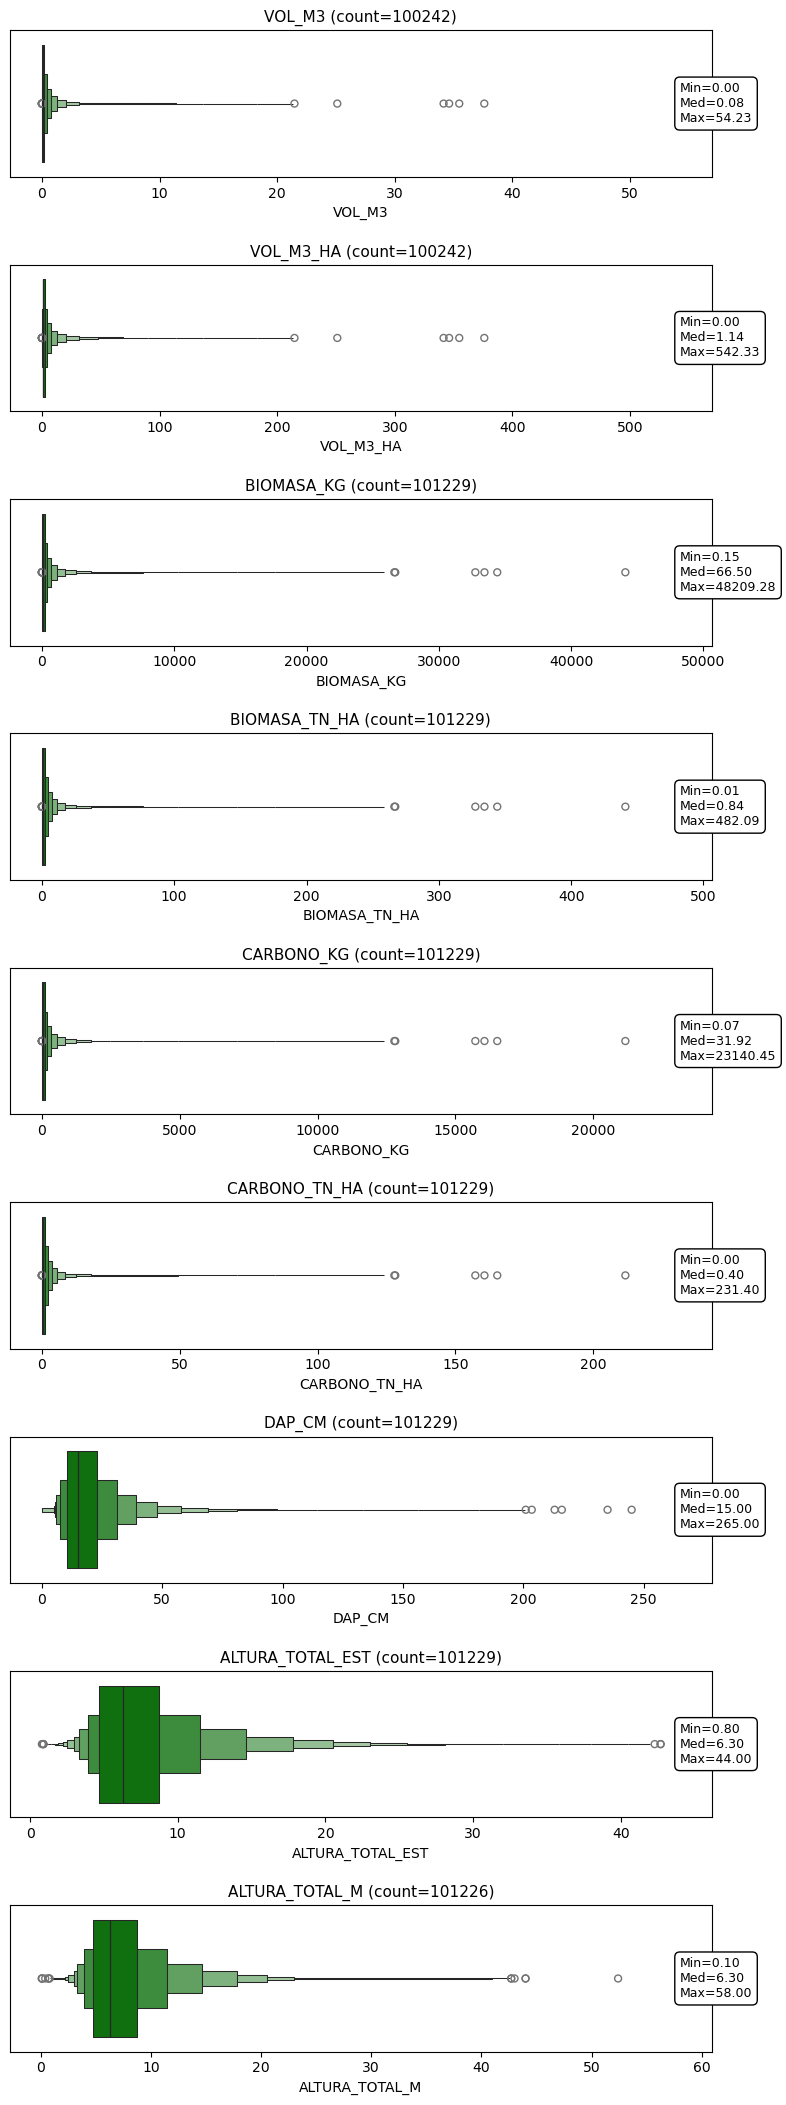

In [335]:
cols_ind = ['VOL_M3','VOL_M3_HA','BIOMASA_KG','BIOMASA_TN_HA','CARBONO_KG','CARBONO_TN_HA','DAP_CM', 'ALTURA_TOTAL_EST', 'ALTURA_TOTAL_M']

n = len(cols_ind)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 2.5 * n), sharex=False)

# Ensure axes is iterable
if n == 1:
    axes = [axes]

for i, col in enumerate(cols_ind):
    data = df_individuos_c[col].dropna()
    count = data.count()
    ax = axes[i]
    
    # Boxenplot horizontal
    sb.boxenplot(x=data, ax=ax, color='green', orient='h')
    
    # Title with count
    ax.set_title(f"{col} (count={count})", fontsize=11)
    ax.set_yticks([])

    # Calculate min, median, max
    percentiles = data.quantile([0.0, 0.5, 1.0])
    min_val, med_val, max_val = percentiles.iloc[0], percentiles.iloc[1], percentiles.iloc[2]

    # Label text
    label_text = f"Min={min_val:.2f}\nMed={med_val:.2f}\nMax={max_val:.2f}"

    # Annotate on the right of the plot
    x_pos = max_val
    y_pos = 0  # single boxenplot, y=0
    ax.text(
        x_pos, y_pos,
        label_text,
        ha='left', va='center',
        fontsize=9, color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.6)
plt.show()

- Después de analizar estas distribuciones decidimos descartar por ahora también de las variables "DAP_CM", "CARBONO_KG" y "BIOMASA_KG" ya que no aportan información nueva y son redundantes.

Eliminamos las variables con muy baja cantidad de datos y las variables redundantes:

In [337]:
df_filtrado_G = df_individuos_c.drop(columns=[
    'DIAMETRO_COPA_2',
    'DIAMETRO_COPA_1',
    'DAB_CM',
    'DAB_FINAL_M',
    'MEDIA_DIAM_COPA',
    'CARBONO_KG',
    'BIOMASA_KG',
    'ALTURA_TOTAL_EST',
    'AREABASAL_M2',
    'VOL_M3',
    'DAP_CM'
])

print(f'Shape Antes: {df_individuos_c.shape}')
print(f'Shape Después: {df_filtrado_G.shape}')

Shape Antes: (101229, 31)
Shape Después: (101229, 20)


##### Aplicamos *one-hot encoding* a variables categóricas con pocas clases y gran cantidad de registros:

- Al transformar estas variables categóricas en **valores binarios numéricos** mediante *one-hot encoding*, **incrementamos significativamente la cantidad de información aprovechable** en los modelos de **aprendizaje automático**, tanto de **clasificación** como de **clustering** que implementaremos más adelante


In [338]:
print(df_filtrado_G.nunique(dropna=True))

UM_ID_UM                       3815
NO_INDIV                        212
PARCELA_CONCENTRICA               2
ESPECIE_CORREGIDA               458
REGION_OFC                        7
SUBREG                           13
ESTADO_INDIV                      6
ALTURA_TOTAL_M                  942
PROVINCIA                        23
COORDENADAS_GPS_LATITUDE2      3781
COORDENADAS_GPS_LONGITUDE2     3788
DAP_FINAL_M                   10856
VOL_M3_HA                     52316
AREABASAL_CM2                 12403
DENSIDAD_MADERA                 168
CLASE_DIAM                       13
BIOMASA_TN_HA                 77538
CARBONO_TN_HA                 77536
Ley_N1_06                         3
Ley_N2_06                        32
dtype: int64


##### Visualización de valores nulos antes aplicar onehot encoding y antes de la imputación de los mismos:

<Axes: >

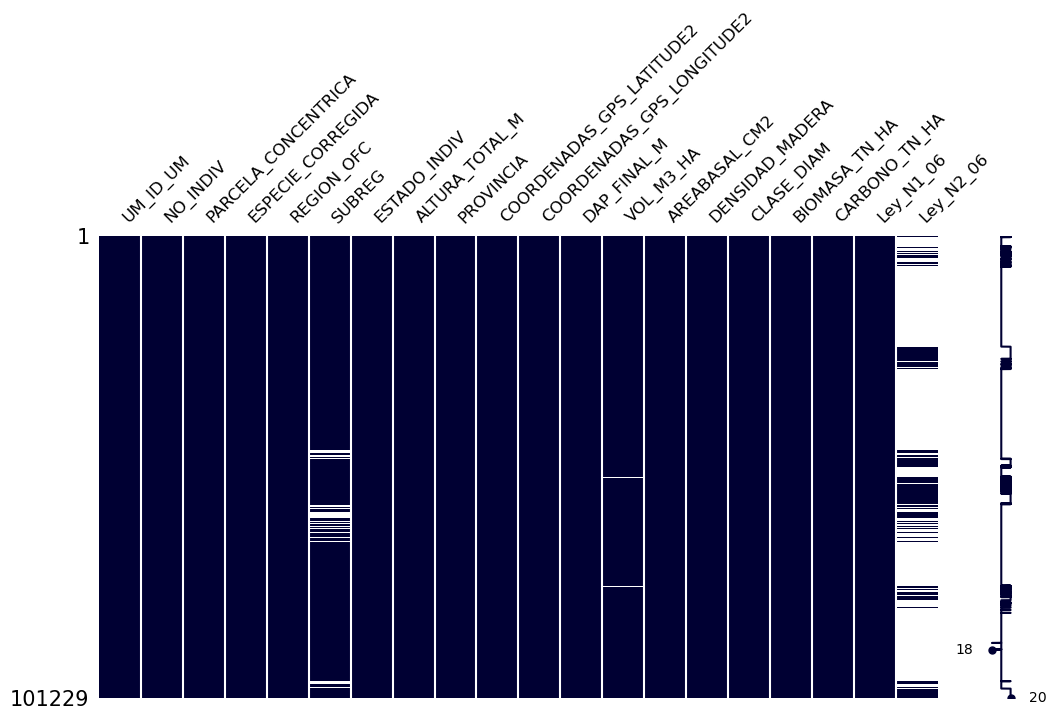

In [339]:
msno.matrix(df_filtrado_G,figsize=(12, 6), fontsize=12, color=[0,0,0.2])

In [340]:
df_individuos_c[['DAP_CM', 'CLASE_DIAM']].head()

,DAP_CM,CLASE_DIAM
0,11.838074,[10-20]
1,10.160709,[10-20]
2,8.221922,[5-10]
3,7.798718,[5-10]
4,12.165525,[10-20]


Siguiendo la lógica anterior vamos a vamos a descartar en este proceso variables categóricas que contengan información redundante o con valores no nulos para pocos registros del dataset.
- En este caso la variable "CLASE_DIAM" contiene información categorizada redundante de la variable "DAP_CM"
- La variable "SUBREG" contiene varios datos faltantes y puede ser reemplazada por la variable "REGION_OFC" de ser necesario.
- La columna "Ley_N2_06" aporta datos no nulos para una proporción pequeña del dataset por lo que no va a aportar información relevante para nuestro modelos.

Por esos motivos decidimos también descartar las variables "SUBREG", "CLASE_DIAM" y "Ley_N2_06".

In [341]:
df_filtrado_B = df_filtrado_G.drop(columns=[
'SUBREG',
'CLASE_DIAM',
'Ley_N2_06'
])

Visualizamos valores nulos una vez más después de descartar las variables antes mencionadas:

<Axes: >

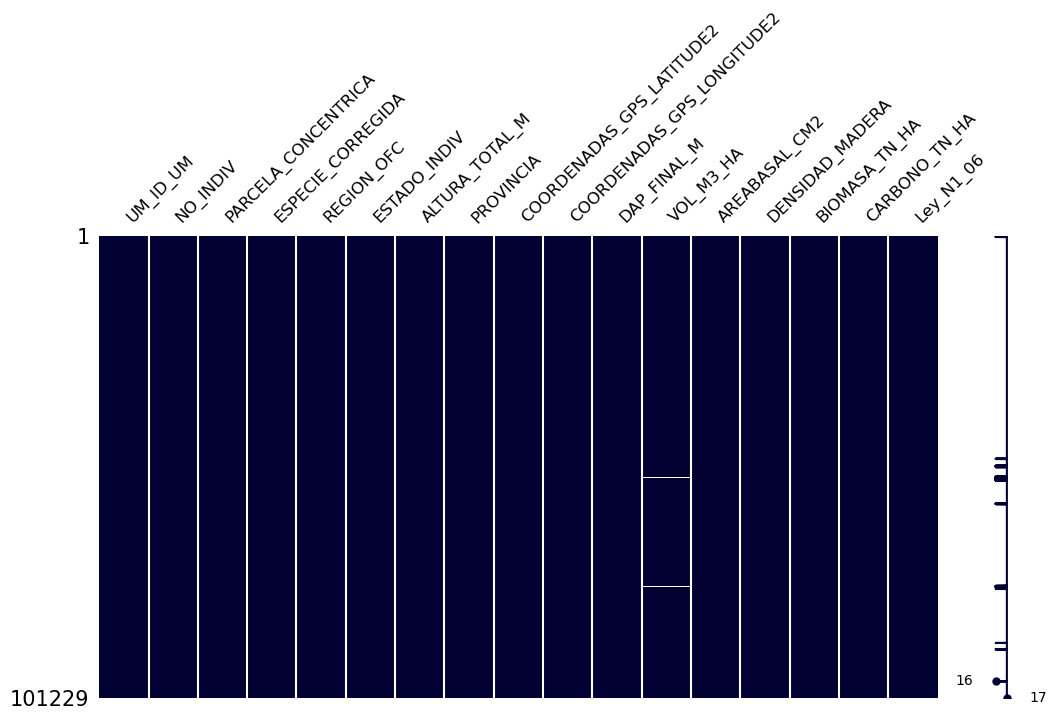

In [342]:
msno.matrix(df_filtrado_B,figsize=(12, 6), fontsize=12, color=[0,0,0.2])

Creamos una pequeña función para detectar valores NaN y obtener la variable afectada:

In [343]:
# Funcion para encontrar los valores nulos 
def check_nans(df):
    # contar NaNs
    nans_por_col = df.isna().sum()
    # Filtrar columns con NaNs
    cols_con_nans = nans_por_col[nans_por_col > 0]
    
    if cols_con_nans.empty:
        print("No hay NaNs en el DataFrame.")
    else:
        print(f"NaNs en {len(cols_con_nans)} cols:")
        for col, count in cols_con_nans.items():
            perc = (count / len(df)) * 100
            print(f"   - {col}: {count} NaNs ({perc:.2f}%)")

check_nans(df_filtrado_B)

NaNs en 2 cols:
   - ALTURA_TOTAL_M: 3 NaNs (0.00%)
   - VOL_M3_HA: 987 NaNs (0.98%)


Imputamos los valores nulos restantes. Como en este caso hay que imputar pocos valores de una sola variable, y la distribución de la misma es claramente sesgadavamos a utilizar Simple Imputer de Scikit-learn con una estrategia de medianas (Imputar los valores nulos es necesario para poder aplicar PCA mas adelante en este Notebook).

In [344]:
cols_to_impute = ['VOL_M3_HA', 'ALTURA_TOTAL_M']
imputer_median = SimpleImputer(strategy='median')

df_filtrado_B[cols_to_impute] = imputer_median.fit_transform(df_individuos[cols_to_impute])

Buscar nuevamente y corroborar que no queden valores nulos en el dataset:

In [345]:
# Funcion para encontrar los valores nulos 
def check_nans(df):
    # contar NaNs
    nans_por_col = df.isna().sum()
    # Filtrar columnas con NaNs
    cols_con_nans = nans_por_col[nans_por_col > 0]
    
    if cols_con_nans.empty:
        print("No hay NaNs en el DataFrame.")
    else:
        print(f"NaNs en {len(cols_con_nans)} cols:")
        for col, count in cols_con_nans.items():
            perc = (count / len(df)) * 100
            print(f"   - {col}: {count} NaNs ({perc:.2f}%)")

check_nans(df_filtrado_B)

No hay NaNs en el DataFrame.


Determinamos las columnas a las que le aplicaremos One Hot Encoding. Utilizamos variables categóricas relevantes para nuestros futuros modelos y que a su vez no tengan un alto numero de clases, así podemos información util sin aumentar demasiado el número de dimensiones en el dataframe.

In [346]:
cols_onehot = [
'PARCELA_CONCENTRICA',
'REGION_OFC',    
'ESTADO_INDIV',   
'Ley_N1_06'
]

In [347]:
df_ind_onehot = pd.get_dummies(df_filtrado_B, columns=cols_onehot, drop_first=False, dtype='int')
print(f'Cantidad de columnas antes del encoding: {df_filtrado_B.shape[1]}')
print(f'Cantidad de columnas después del encoding: {df_ind_onehot.shape[1]}')
print("")
print("Ejemplo después del onehot encoding: ")
df_ind_onehot[[col for col in df_ind_onehot.columns if 'PARCELA_CONCENTRICA' in col]].head()

Cantidad de columnas antes del encoding: 17
Cantidad de columnas después del encoding: 31

Ejemplo después del onehot encoding: 


,PARCELA_CONCENTRICA_A,PARCELA_CONCENTRICA_B
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


##### Visualización después de la imputación final y del one hot encoding:

<Axes: >

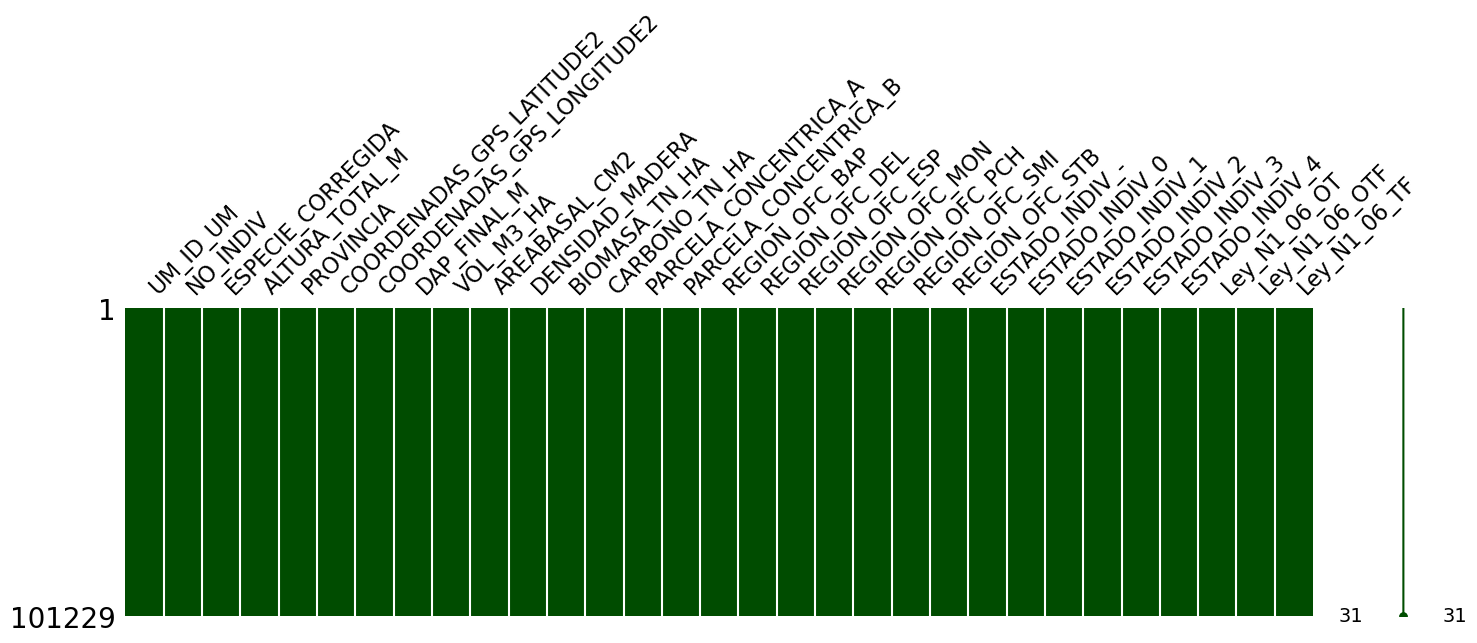

In [348]:
msno.matrix(df_ind_onehot,figsize=(17, 4), color=[0,0.3,0])

### Aplicamos PCA para determinar los componentes principales y como estrategia para reducir la dimensionalidad del conjunto de datos, y además descargamos el dataframe final obtenido a un archivo de tipo .csv en el ambiente local

In [349]:
df_ind_onehot_C = df_ind_onehot.copy()
one_hot_num_cols = df_ind_onehot_C.select_dtypes(include=['number']).columns.tolist()
print("Columnas numéricas despues del tratamiento:", one_hot_num_cols)

Columnas numéricas despues del tratamiento: ['UM_ID_UM', 'NO_INDIV', 'ALTURA_TOTAL_M', 'PROVINCIA', 'COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2', 'DAP_FINAL_M', 'VOL_M3_HA', 'AREABASAL_CM2', 'DENSIDAD_MADERA', 'BIOMASA_TN_HA', 'CARBONO_TN_HA', 'PARCELA_CONCENTRICA_A', 'PARCELA_CONCENTRICA_B', 'REGION_OFC_BAP', 'REGION_OFC_DEL', 'REGION_OFC_ESP', 'REGION_OFC_MON', 'REGION_OFC_PCH', 'REGION_OFC_SMI', 'REGION_OFC_STB', 'ESTADO_INDIV_-', 'ESTADO_INDIV_0', 'ESTADO_INDIV_1', 'ESTADO_INDIV_2', 'ESTADO_INDIV_3', 'ESTADO_INDIV_4', 'Ley_N1_06_OT', 'Ley_N1_06_OTF', 'Ley_N1_06_TF']


In [350]:

# Estandarizamos (muy importante para PCA)
# instanciamos el scaler
scaler = StandardScaler()
#transformamos la matriz
X_scaled = scaler.fit_transform(df_ind_onehot_C[one_hot_num_cols])

# Definir cuántas componentes pedir con el parámetro dado en el ejercicio
n = min(20, X_scaled.shape[0])

# instanciamos el objeto PCA
pca = PCA(n_components=n, random_state=42)
# transformamos la matriz previamente escalada
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame con las dos primeras componentes
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=['PCA1', 'PCA2'],
    index=df_ind_onehot_C.index  # para alinear correctamente al concatenar
)

# Concatenar al DataFrame original
df_final_ind = pd.concat([df_ind_onehot_C, pca_df], axis=1)

print("Shape final con PCs:", df_final_ind.shape)

# Descarga el cvs en ambiente local.
df_final_ind.to_csv("df_final_individuos.csv", header=True, index=False)
print(f"Archivo 'df_final_individuos.csv' generado con {df_final_ind.shape[0]} filas")

Shape final con PCs: (101229, 33)
Archivo 'df_final_individuos.csv' generado con 101229 filas


#### Matriz de correlación final incluyendo las variables de los dos primeros componentes resultantes del PCA: 

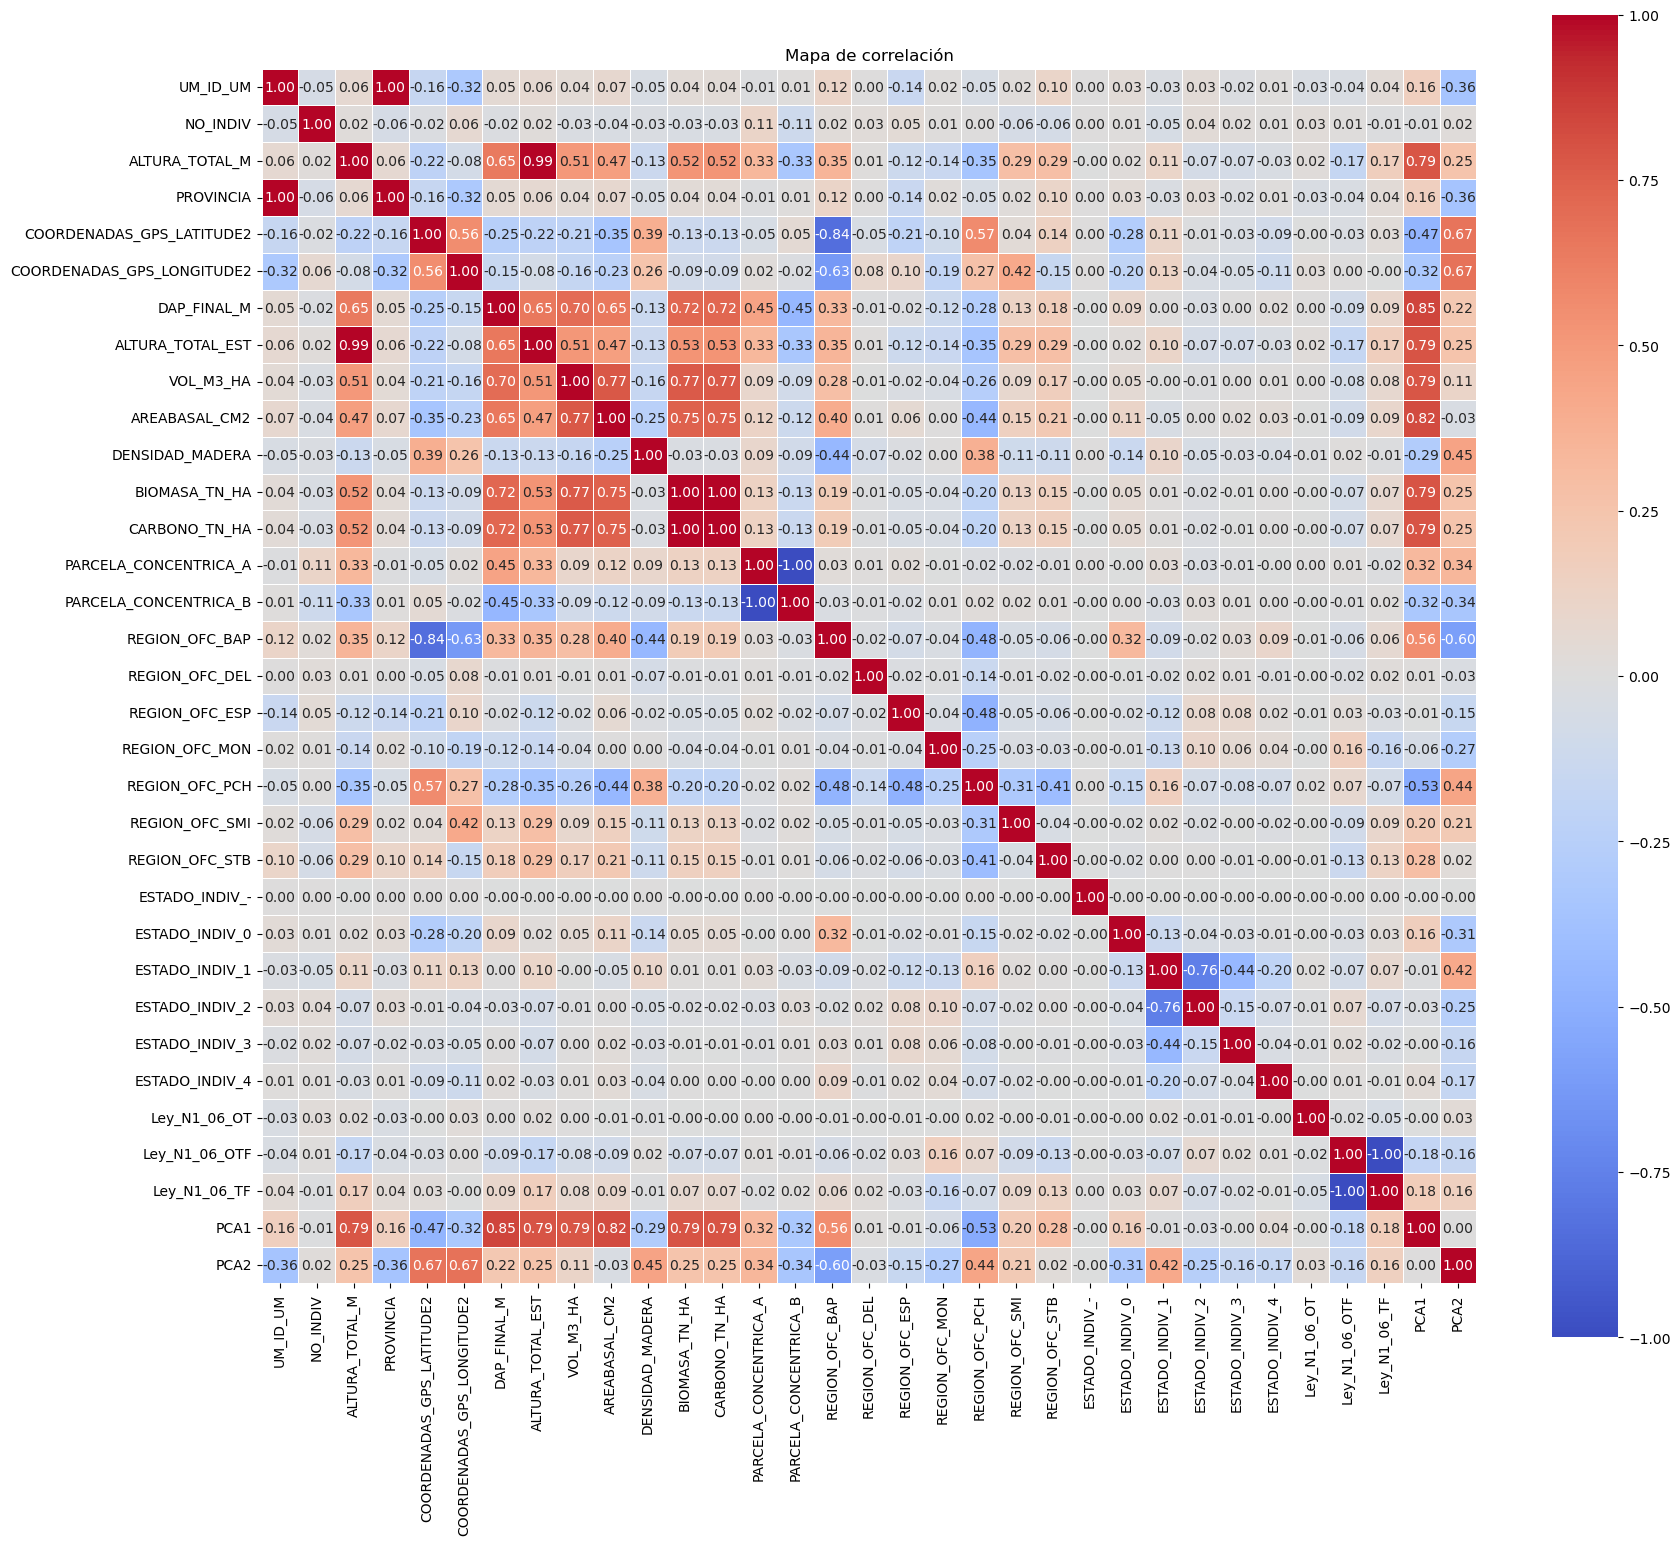

In [334]:

variables = df_final_ind.select_dtypes(include=['number']).columns.tolist()

# Eliminar filas con valores faltantes en estas columnas
df_corr = df_final_ind[variables].dropna()

# Calcular la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')

# Crear el mapa de calor
plt.figure(figsize=(18,18))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()